In [5]:
root_dir = './' 
# please make sure the ref_adata and the query_adata are in the root_dir
objs = ['scRNA_ref_adata.h5ad---scRNA_query_adata.h5ad']
# ['{ref_adata1}---{query_adata1}','{ref_adata2}---{query_adata2}']

In [6]:
config_dict = {
    'annotation_mode':'default', # 'default','st'
    # st is for spatial data
    'identification_mode':'default', # 'default','csi'
    # csi is for cell subtype identification
    # when cell types in ref_adata may be different from those in query_adata, you can try 'csi'
    'run_mode':'cpu+gpu', # 'cpu+gpu','cpu_only'
    # when 'cpu_only', some frameworks can not work, the performance may be lower
    'framework_mode':'default', # 'default','rc_weighted'
    # when the result is not good enough, using 'rc_weighted' may be better 
    'save_dir':'./',
    'random_seeds':[42],
    'celltype_label':'Celltype', 
    # when 'celltype_label' is 'xxx'
    # please make sure the celltype labels are in ref_adata.obs['xxx'] and query_adata.obs['xxx']
    # you can set query_adata.obs['celltype'] = 'not_clear'
    'celltype_filterlist':['Unknow','Unknown'],
    # in ref_adata and query_adata, remove cells which cell type labels are in the 'celltype_filterlist'
    'gpu_code':'0',
    # which gpu to use
}

In [7]:
with open('PCmaster_anno.v.0.0.2.py','r',encoding='utf-8') as f:
    exec(f.read())

pcma = PCmaster_anno_0()

2024-09-01 16:42:36
available_memory: 22.739086151123047 GB
used_memory: 9.117412567138672 GB
2024-09-01 16:42:36
available_memory: 22.738346099853516 GB
used_memory: 9.117179870605469 GB
2024-09-01 16:42:36
available_memory: 22.735919952392578 GB
used_memory: 9.119606018066406 GB


At the epoch 16, the model got the best valid accuracy 0.7879611330698287.
loss 0.020, train acc 0.994, valid acc 0.788
45353.8 examples/sec on cuda:0
memory used: 3.0808639526367188 GB
mapping_1_test,mapping_2_test
{'Mesophyll': 0, 'Bundle sheath': 1, 'Phloem parenchyma': 2, 'Leaf pavement cell': 3, 'Companion cell': 4, 'Leaf guard cell': 5, 'Hydathodes': 6}
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6}
mapping_1,mapping_2
{'G2/M phase': 0, 'Root cortex': 1, 'Root cap': 2, 'S phase': 3, 'Root hair': 4, 'Lateral root cap': 5, 'Non-hair': 6, 'Phloem': 7, 'Columella root cap': 8, 'Root endodermis': 9, 'Xylem': 10, 'G1/G0 phase': 11, 'Root stele': 12, 'Mesophyll': 13, 'Bundle sheath': 14, 'Phloem parenchyma': 15, 'Leaf pavement cell': 16, 'Companion cell': 17, 'Leaf guard cell': 18, 'Hydathodes': 19, 'Shoot system epidermis': 20, 'Cortex': 21, 'Vascular cambium': 22, 'Flower meristem': 23, 'Leaf epidermis': 24, 'Stress response': 25, 'Meristematic cell': 26, 'Vascular tissue': 27, 'Shoot api

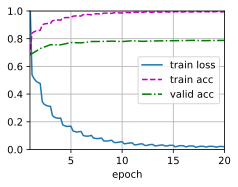

In [8]:
pcma_annotation_mygo(config_dict = config_dict)

In [9]:
save_dir = config_dict['save_dir']
obj = objs[0]
random_seed = config_dict['random_seeds'][0]

with open(save_dir+'test_label_'+str(obj)+'_'+str(random_seed)+'.pkl','rb') as file:
    test_label_unmapped = pickle.load(file)
with open(save_dir+'predicted_'+str(obj)+'_'+str(random_seed)+'.pkl','rb') as file:
    predicted_unmapped = pickle.load(file)
with open(save_dir+'ref_mapping_'+str(obj)+'_'+str(random_seed)+'.pkl','rb') as file:
    ref_mapping = pickle.load(file)

In [10]:
scobj = sc.read(root_dir+objs[0].split('---')[1])

print(len(scobj.obs_names))
print(len(test_label_unmapped))

scobj.obs['Prediction'] = predicted_unmapped

scobj = scobj[scobj.obs[config_dict['celltype_label']].isin(ref_mapping.keys())]

2793
2793


scanpy==1.9.5 anndata==0.9.1 umap==0.5.4 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.2.1 statsmodels==0.14.0 igraph==0.10.8 louvain==0.8.1 pynndescent==0.5.10


Before filter


normalizing counts per cell
    finished (0:00:00)


d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


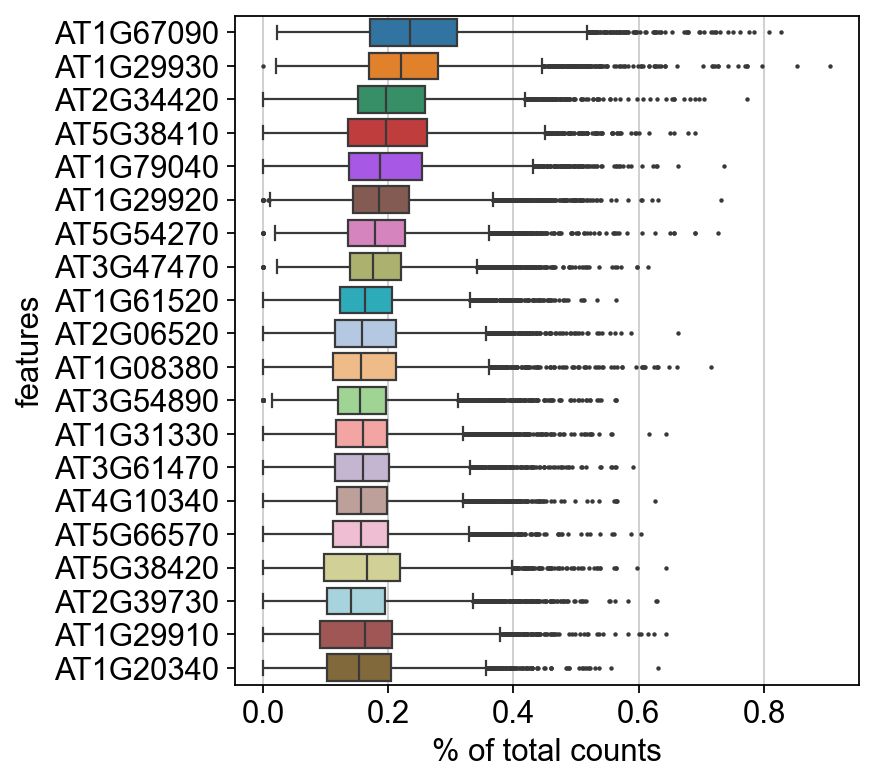

d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\plotting\_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


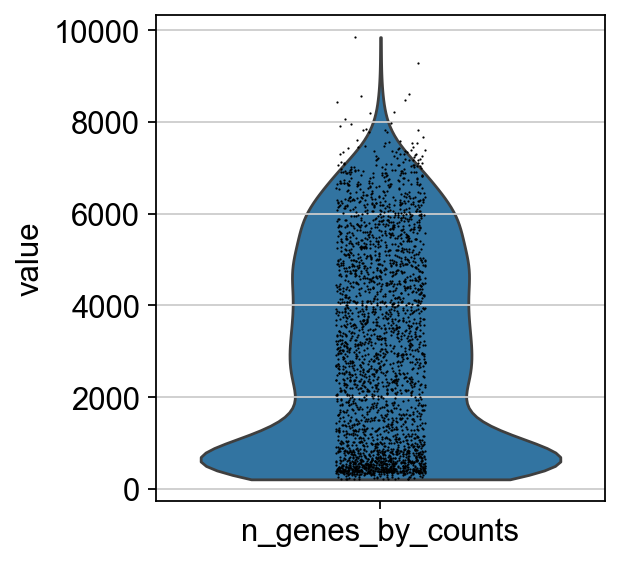

d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\plotting\_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


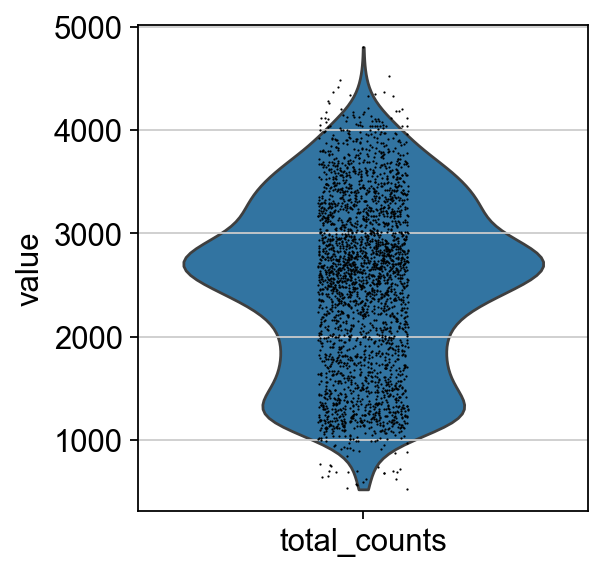

d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\plotting\_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


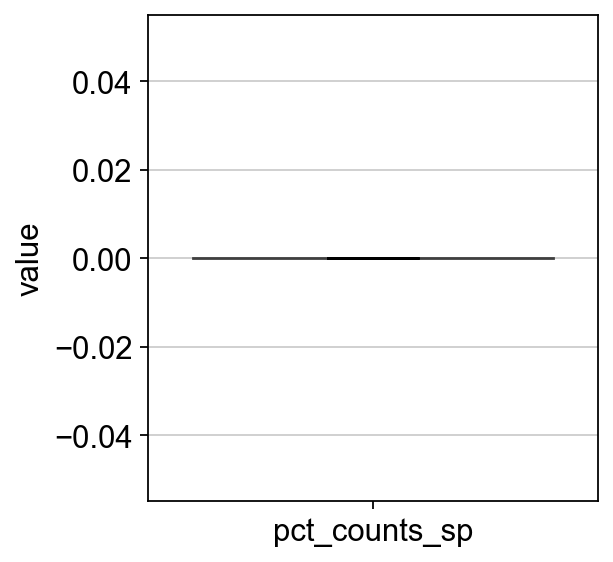

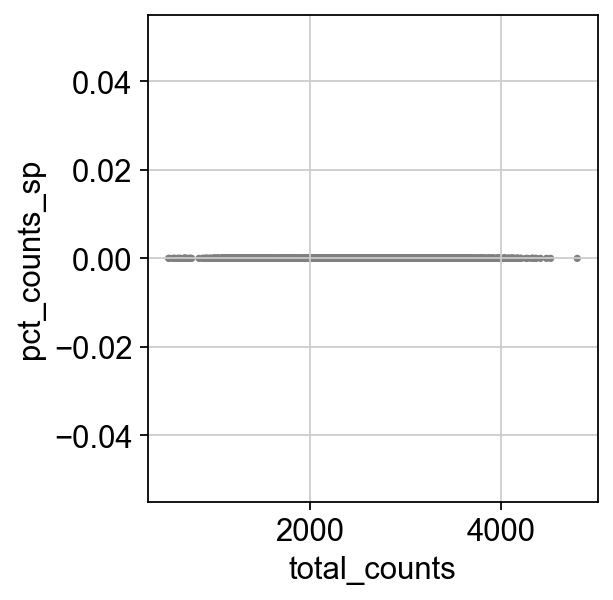

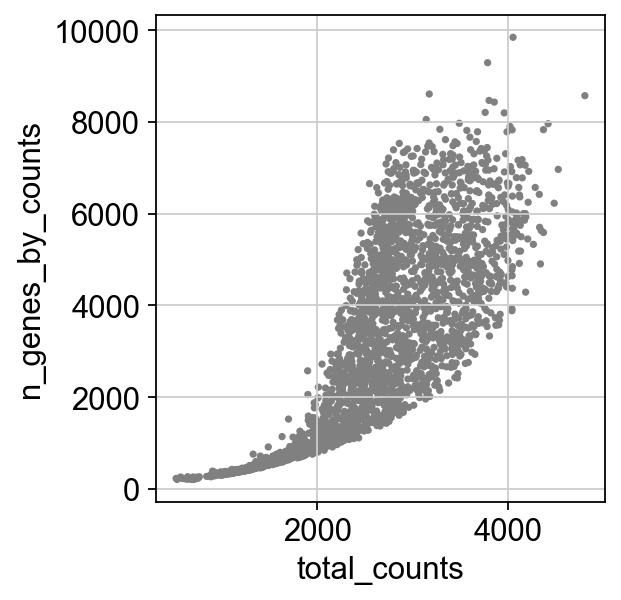



After filter


filtered out 32154 genes that are detected in less than 3 cells


d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\plotting\_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


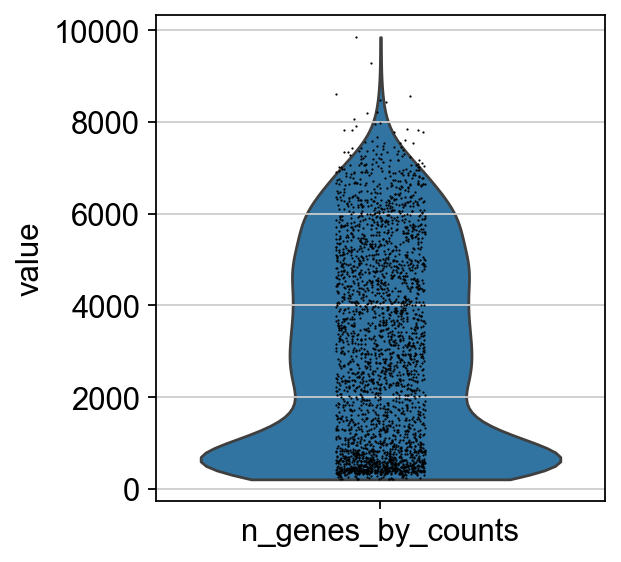

d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\plotting\_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


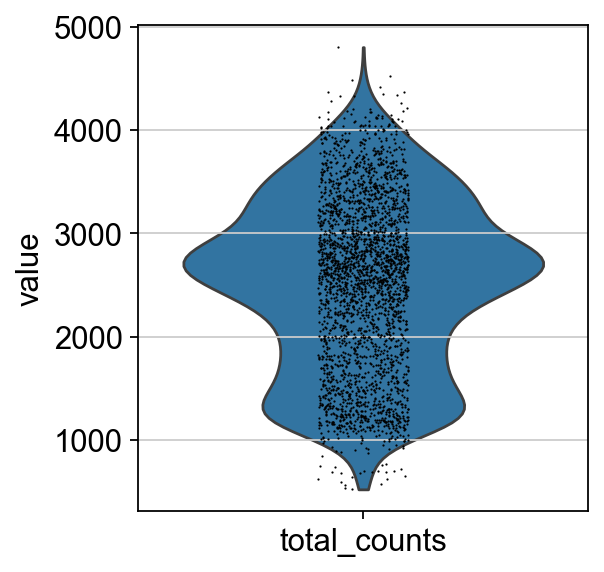

d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\plotting\_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


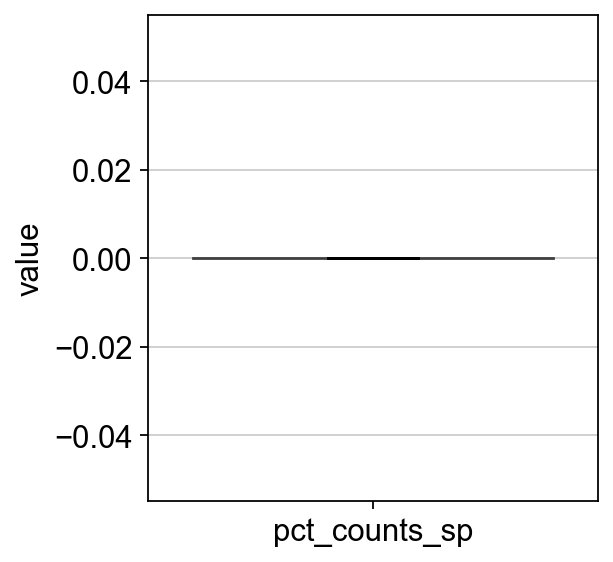

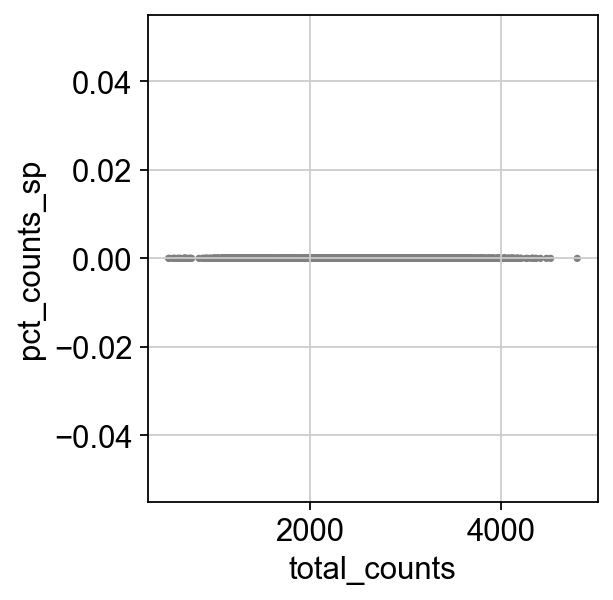

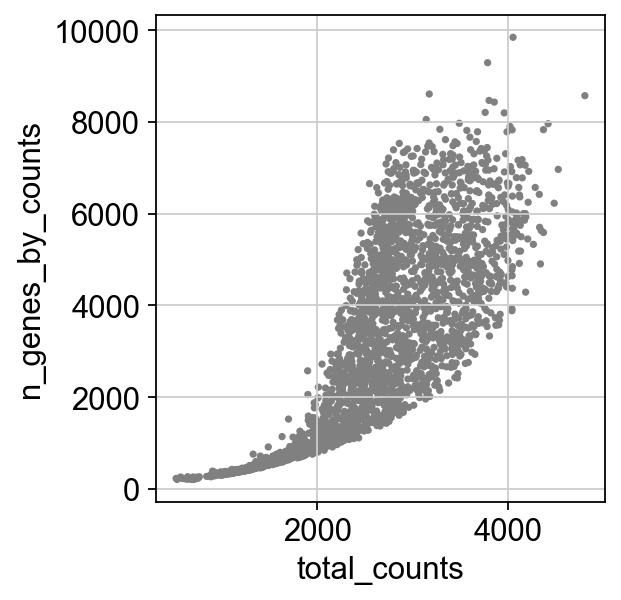



Before filter


count    2793.000000
mean     2516.598097
std       825.168536
min       520.946996
25%      1857.928861
50%      2614.149044
75%      3130.921381
max      4802.391028
Name: total_counts, dtype: float64
count    2793.000000
mean     3034.377730
std      2152.665519
min       206.000000
25%       858.000000
50%      2827.000000
75%      4844.000000
max      9846.000000
Name: n_genes_by_counts, dtype: float64
count    2793.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: pct_counts_sp, dtype: float64


After filter


count    2793.000000
mean     2516.598097
std       825.168536
min       520.946996
25%      1857.928861
50%      2614.149044
75%      3130.921381
max      4802.391028
Name: total_counts, dtype: float64
count    2793.000000
mean     3034.377730
std      2152.665519
min       206.000000
25%       858.000000
50%      2827.000000
75%      4844.000000
max      9846.000000
Name: n_genes_by_co

d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


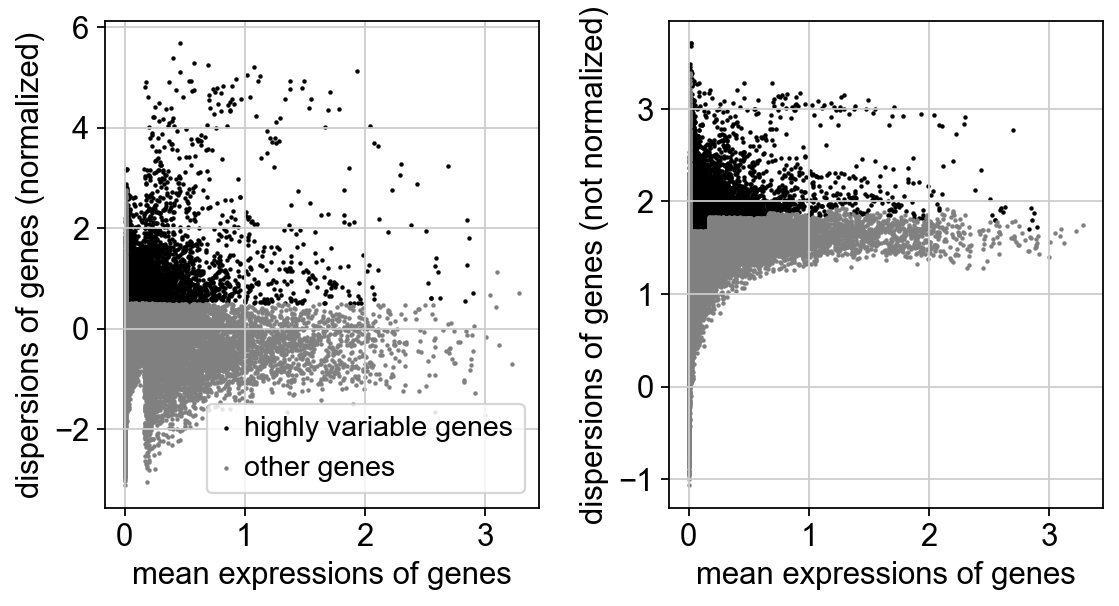

regressing out ['total_counts']
    sparse input is densified and may lead to high memory use
    finished (0:00:12)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:01)


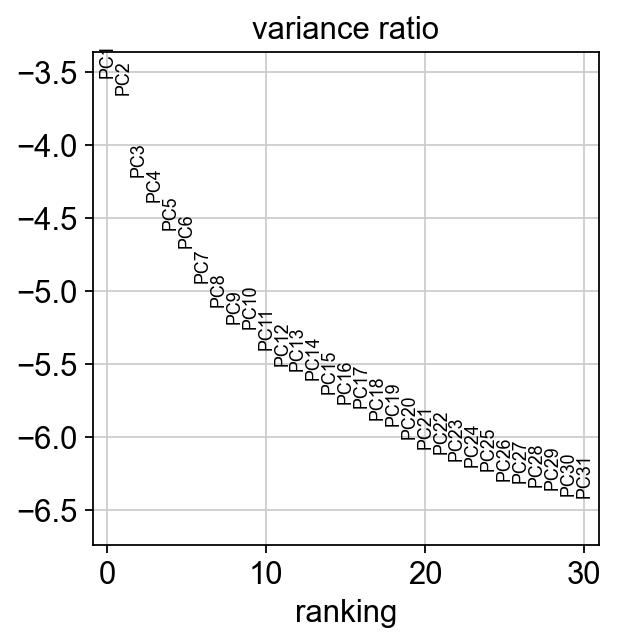

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:03)
running Leiden clustering
    finished: found 21 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


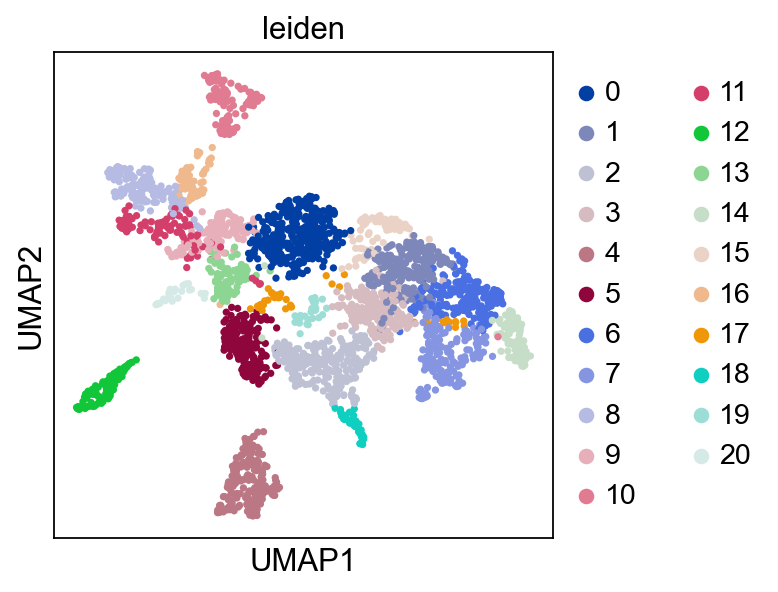

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\tools\_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\tools\_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\t

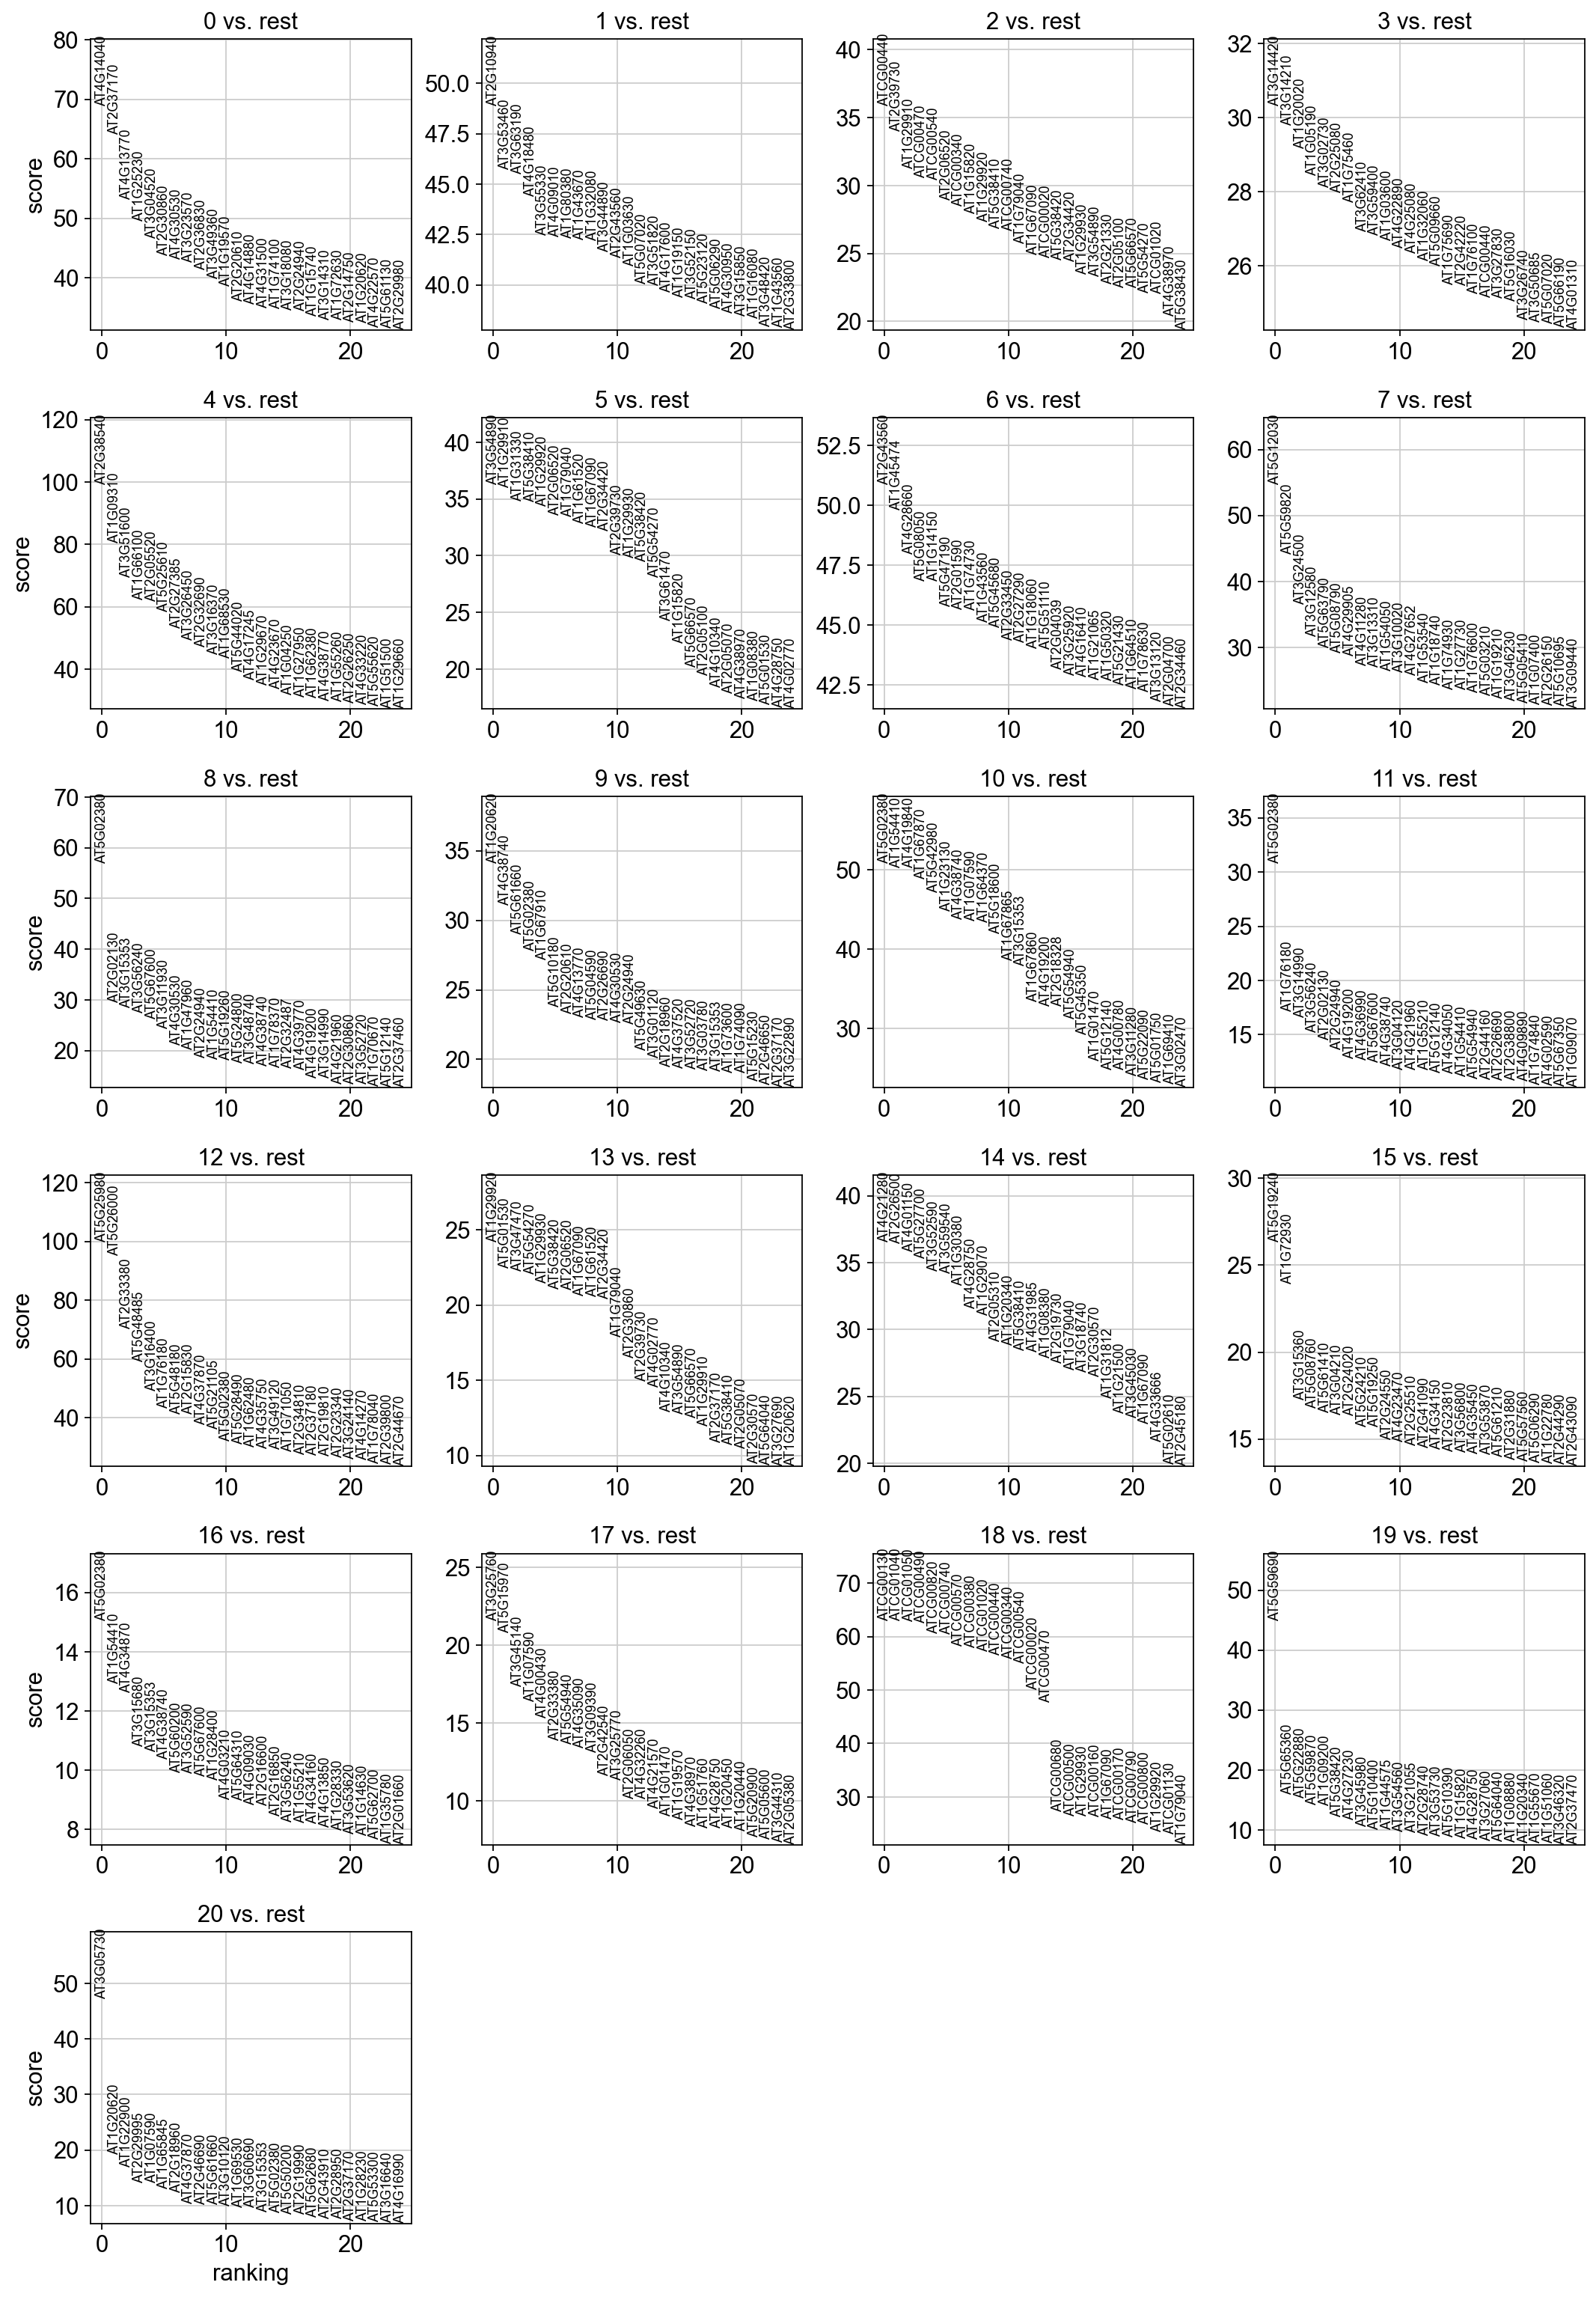



The below is the top marker gene list for each cluster.
            You can change the annotation result according to this.


The list of top marker genes 
 col : clusters


            0          1          2          3          4          5  \
0   AT4G14040  AT2G10940  ATCG00440  AT3G14420  AT2G38540  AT3G54890   
1   AT2G37170  AT3G53460  AT2G39730  AT3G14210  AT1G09310  AT1G29910   
2   AT4G13770  AT3G63190  AT1G29910  AT1G20020  AT3G51600  AT1G31330   
3   AT1G25230  AT4G18480  ATCG00470  AT1G05190  AT1G66100  AT5G38410   
4   AT3G04520  AT3G55330  ATCG00540  AT3G02730  AT2G05520  AT1G29920   
5   AT2G30860  AT4G09010  AT2G06520  AT2G25080  AT5G25610  AT2G06520   
6   AT4G30530  AT1G80380  ATCG00340  AT1G75460  AT2G27385  AT1G79040   
7   AT3G23570  AT1G43670  AT1G15820  AT3G62410  AT3G26450  AT1G61520   
8   AT2G36830  AT1G32080  AT1G29920  AT3G59400  AT2G32690  AT1G67090   
9   AT3G49360  AT3G44890  AT5G38410  AT1G03600  AT3G16370  AT2G34420   
10  AT1G19570  AT2G43560  ATCG00

In [11]:
pcma = PCmaster_anno_0()
pcma.to_clusters_0(anndata=scobj)

d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


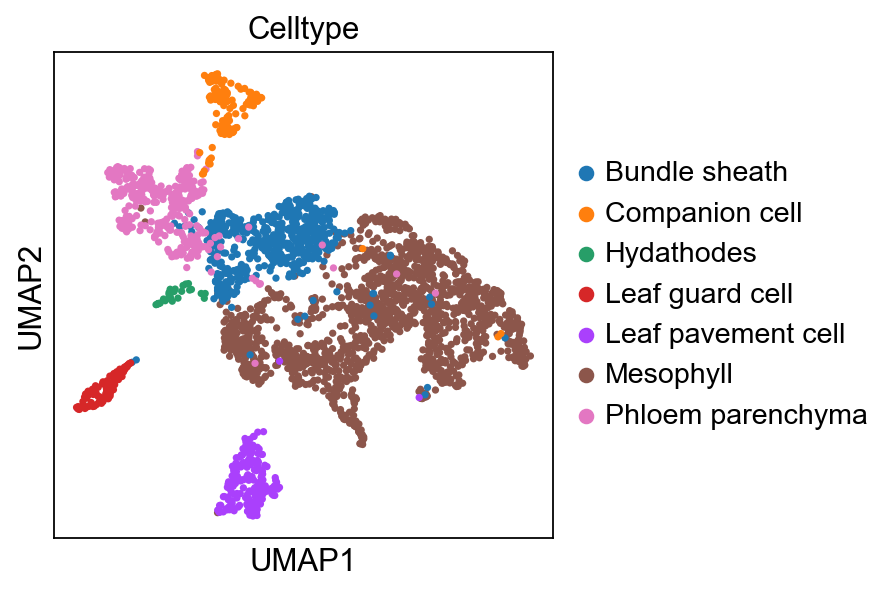

d:\aaa-new\setups\conda\conda-files\envs\PCmaster_anno_win\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


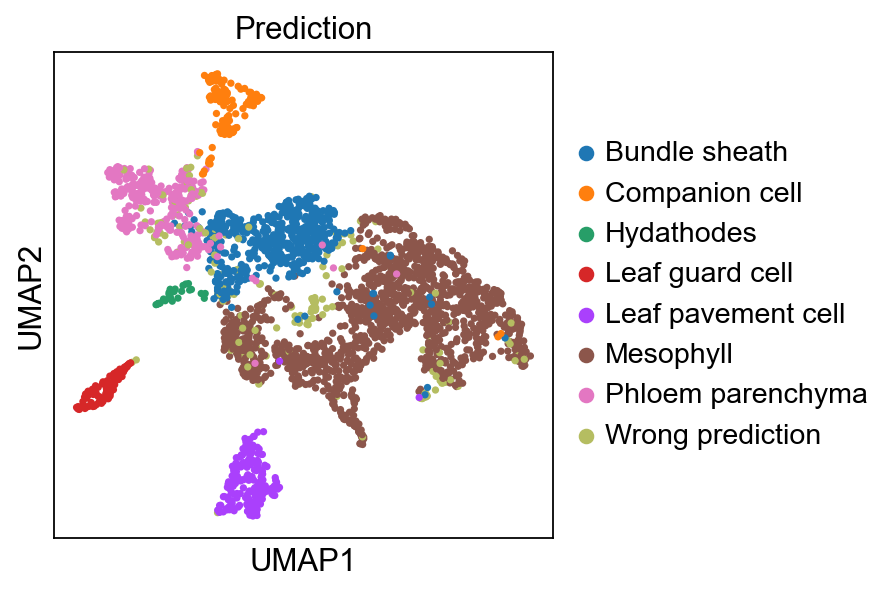

In [12]:
sc.pl.umap(pcma.obj,color=config_dict['celltype_label'])

tmplist21 = pcma.obj.obs[config_dict['celltype_label']]
tmplist22 = []
for i,j in enumerate(list(pcma.obj.obs['Prediction'])):
    if j != tmplist21[i]:
        tmplist22.append('Wrong prediction')
    else:
        tmplist22.append(j)

pcma.obj.obs['Prediction'] = tmplist22
sc.pl.umap(pcma.obj,color='Prediction')